In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent

PROCESSED_PATH = PROJECT_ROOT / "processed"

MASTER_FILE = PROCESSED_PATH / "bengaluru_crashes_station_master.csv"

# Load master dataset
df = pd.read_csv(MASTER_FILE)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nYears:")
print(sorted(df["year"].unique()))

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (371, 9)

Columns:
['zone', 'sub_division', 'station', 'year', 'fatal_crashes', 'nonfatal_crashes', 'total_crashes', 'people_killed', 'people_injured']

Years:
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

First 5 rows:


,zone,sub_division,station,year,fatal_crashes,nonfatal_crashes,total_crashes,people_killed,people_injured
0,East,NaN,Adugodi,2018,3,47,50,3.0,53.0
1,East,NaN,Airport,2018,24,85,109,26.0,77.0
2,East,NaN,Ashokanagar,2018,4,51,55,4.0,55.0
3,East,NaN,Banasawadi,2018,21,108,129,21.0,133.0
4,East,NaN,Cubbon Park,2018,2,52,54,2.0,53.0


In [2]:
# Check how many years of data are available for each station

station_years = (
    df.groupby("station")["year"]
      .agg(
          years_available="nunique",
          first_year="min",
          last_year="max"
      )
      .reset_index()
      .sort_values(
          ["years_available", "station"],
          ascending=[False, True]
      )
)

print("Number of unique stations:", len(station_years))

display(station_years)

Number of unique stations: 60


,station,years_available,first_year,last_year
0,Adugodi,8,2018,2025
1,Airport,8,2018,2025
2,Ashokanagar,8,2018,2025
4,Banasawadi,8,2018,2025
5,Banashankari,8,2018,2025
6,Basavanagudi,8,2018,2025
9,Chamarajpet,8,2018,2025
12,Chikkajala,8,2018,2025
13,City Market,8,2018,2025
14,Cubbon Park,8,2018,2025


In [3]:
# Select stations with complete 8-year historical coverage

forecast_stations = station_years[
    (station_years["years_available"] == 8) &
    (station_years["first_year"] == 2018) &
    (station_years["last_year"] == 2025)
]["station"].tolist()

print("Stations eligible for forecasting:", len(forecast_stations))

print("\nForecasting stations:")
print(forecast_stations)

Stations eligible for forecasting: 37

Forecasting stations:
['Adugodi', 'Airport', 'Ashokanagar', 'Banasawadi', 'Banashankari', 'Basavanagudi', 'Chamarajpet', 'Chikkajala', 'City Market', 'Cubbon Park', 'Electronic City', 'H.Grounds', 'HSR Layout', 'Hebbala', 'Hulimavu', 'Indiranagar', 'Jalahalli', 'Jayanagar', 'K G Halli', 'K R Puram', 'Kamakshipalya', 'Kengeri', 'Madivala', 'Magadi Road', 'Malleshwaram', 'Micolayout', 'Peenya', 'R T Nagar', 'Rajajinagar', 'S.S.Nagar', 'Shivajinagar', 'U.Gate', 'Upparpet', 'Vijayanagar', 'W.Garden', 'Whitefield', 'Yalahanka']


In [4]:
# Verify continuous yearly coverage

expected_years = set(range(2018, 2026))

coverage_check = []

for station in forecast_stations:
    station_years_present = set(
        df.loc[df["station"] == station, "year"]
    )

    missing_years = sorted(expected_years - station_years_present)

    coverage_check.append({
        "station": station,
        "missing_years": missing_years,
        "complete": len(missing_years) == 0
    })

coverage_check_df = pd.DataFrame(coverage_check)

display(coverage_check_df)

print(
    "\nAll selected stations have complete coverage:",
    coverage_check_df["complete"].all()
)

,station,missing_years,complete
0,Adugodi,[],True
1,Airport,[],True
2,Ashokanagar,[],True
3,Banasawadi,[],True
4,Banashankari,[],True
5,Basavanagudi,[],True
6,Chamarajpet,[],True
7,Chikkajala,[],True
8,City Market,[],True
9,Cubbon Park,[],True



All selected stations have complete coverage: True


In [6]:
# ---------------------------------------------------------
# Forecasting Model Validation
# ---------------------------------------------------------

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


validation_results = []


for station in forecast_stations:

    station_data = (
        df[df["station"] == station]
        .sort_values("year")
        [["year", "total_crashes"]]
        .copy()
    )

    # Test predictions for 2023, 2024 and 2025
    for validation_year in [2023, 2024, 2025]:

        train = station_data[
            station_data["year"] < validation_year
        ]

        actual = station_data.loc[
            station_data["year"] == validation_year,
            "total_crashes"
        ].iloc[0]

        # -------------------------------------------------
        # Model 1: Last-year baseline
        # -------------------------------------------------

        last_year_prediction = train["total_crashes"].iloc[-1]


        # -------------------------------------------------
        # Model 2: 3-year moving average
        # -------------------------------------------------

        moving_average_prediction = (
            train["total_crashes"]
            .tail(3)
            .mean()
        )


        # -------------------------------------------------
        # Model 3: Linear trend
        # -------------------------------------------------

        X_train = train[["year"]]
        y_train = train["total_crashes"]

        linear_model = LinearRegression()
        linear_model.fit(X_train, y_train)

        linear_prediction = linear_model.predict(
    pd.DataFrame({"year": [validation_year]})
)[0]

        # Crash counts cannot be negative
        linear_prediction = max(0, linear_prediction)


        # Store results
        validation_results.append({
            "station": station,
            "validation_year": validation_year,
            "actual": actual,
            "last_year_prediction": last_year_prediction,
            "moving_average_prediction": moving_average_prediction,
            "linear_prediction": linear_prediction
        })


validation_df = pd.DataFrame(validation_results)

print("Validation records:", len(validation_df))

display(validation_df.head(10))

Validation records: 111


,station,validation_year,actual,last_year_prediction,moving_average_prediction,linear_prediction
0,Adugodi,2023,63,42,30.000000,22.700000
1,Adugodi,2024,50,63,41.333333,43.666667
2,Adugodi,2025,66,50,51.666667,47.142857
3,Airport,2023,97,83,96.666667,98.700000
4,Airport,2024,96,97,107.666667,98.266667
5,Airport,2025,74,96,92.000000,97.428571
6,Ashokanagar,2023,38,35,39.000000,28.600000
7,Ashokanagar,2024,35,38,38.333333,28.666667
8,Ashokanagar,2025,40,35,36.000000,27.428571
9,Banasawadi,2023,91,116,102.000000,96.000000


In [7]:
# Check which stations are missing validation years

expected_validation_years = {2023, 2024, 2025}

validation_coverage = (
    validation_df
    .groupby("station")["validation_year"]
    .apply(set)
    .reset_index()
)

validation_coverage["missing_years"] = validation_coverage[
    "validation_year"
].apply(
    lambda x: sorted(expected_validation_years - x)
)

incomplete_validation = validation_coverage[
    validation_coverage["missing_years"].apply(len) > 0
]

display(incomplete_validation)

print(
    "Stations with incomplete validation:",
    len(incomplete_validation)
)

,station,validation_year,missing_years


Stations with incomplete validation: 0


In [8]:
print("Forecast stations:", len(forecast_stations))
print("Validation records:", len(validation_df))
print("Expected records:", len(forecast_stations) * 3)

Forecast stations: 37
Validation records: 111
Expected records: 111


In [9]:
# ---------------------------------------------------------
# Compare Forecasting Models
# ---------------------------------------------------------

model_metrics = []

models = {
    "Last Year": "last_year_prediction",
    "3-Year Moving Average": "moving_average_prediction",
    "Linear Trend": "linear_prediction"
}


for model_name, prediction_column in models.items():

    actual_values = validation_df["actual"]
    predicted_values = validation_df[prediction_column]

    mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            predicted_values
        )
    )

    model_metrics.append({
        "model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2)
    })


model_comparison = (
    pd.DataFrame(model_metrics)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(model_comparison)

,model,MAE,RMSE
0,Last Year,21.41,31.66
1,3-Year Moving Average,23.68,34.56
2,Linear Trend,27.47,41.06


In [10]:
# ---------------------------------------------------------
# Generate 2026 Crash Forecast
# ---------------------------------------------------------

# Use the best-performing model from validation:
# Previous year's crash count

forecast_2026 = []

for station in forecast_stations:

    station_data = (
        df[df["station"] == station]
        .sort_values("year")
        .copy()
    )

    # 2025 actual crash count
    actual_2025 = station_data.loc[
        station_data["year"] == 2025,
        "total_crashes"
    ].iloc[0]

    # Last-year model:
    # 2026 prediction = 2025 actual
    predicted_2026 = actual_2025

    # Calculate recent trend using 2023-2025
    recent_data = station_data[
        station_data["year"].isin([2023, 2024, 2025])
    ]

    trend_per_year = np.polyfit(
        recent_data["year"],
        recent_data["total_crashes"],
        1
    )[0]

    forecast_2026.append({
        "station": station,
        "actual_2025_crashes": actual_2025,
        "predicted_2026_crashes": predicted_2026,
        "recent_trend_per_year": trend_per_year
    })


forecast_2026_df = pd.DataFrame(forecast_2026)

# Round trend values
forecast_2026_df["recent_trend_per_year"] = (
    forecast_2026_df["recent_trend_per_year"].round(2)
)

# Sort by predicted crashes
forecast_2026_df = (
    forecast_2026_df
    .sort_values(
        "predicted_2026_crashes",
        ascending=False
    )
    .reset_index(drop=True)
)

print("2026 forecasts generated:", len(forecast_2026_df))

display(forecast_2026_df.head(15))

2026 forecasts generated: 37


,station,actual_2025_crashes,predicted_2026_crashes,recent_trend_per_year
0,K R Puram,267,267,6.5
1,Yalahanka,257,257,10.5
2,Chikkajala,214,214,38.5
3,Kengeri,200,200,-39.5
4,Kamakshipalya,193,193,-24.0
5,Electronic City,178,178,-9.0
6,Peenya,167,167,-12.5
7,Hebbala,164,164,10.0
8,Banasawadi,101,101,5.0
9,Indiranagar,98,98,6.5


In [11]:
# ---------------------------------------------------------
# Create Predictive Risk Outlook
# ---------------------------------------------------------

# Load our existing station risk information
risk_file = PROCESSED_PATH / "dashboard_station_master.csv"

risk_df = pd.read_csv(risk_file)

# Keep only the columns needed for the predictive analysis
risk_columns = [
    "station",
    "risk_score",
    "risk_category",
    "priority_index",
    "priority_category"
]

risk_info = risk_df[risk_columns].copy()


# ---------------------------------------------------------
# Merge forecast + existing risk information
# ---------------------------------------------------------

predictive_df = forecast_2026_df.merge(
    risk_info,
    on="station",
    how="left"
)


# ---------------------------------------------------------
# Forecast level score
# ---------------------------------------------------------
# Higher predicted crash counts receive a higher score.

predictive_df["forecast_level_score"] = (
    predictive_df["predicted_2026_crashes"]
    .rank(pct=True) * 100
)


# ---------------------------------------------------------
# Recent trend score
# ---------------------------------------------------------
# Positive trends indicate increasing crash activity.
# Negative trends indicate decreasing activity.

predictive_df["trend_score"] = np.select(
    [
        predictive_df["recent_trend_per_year"] >= 10,
        predictive_df["recent_trend_per_year"] > 0,
        predictive_df["recent_trend_per_year"] >= -10,
        predictive_df["recent_trend_per_year"] < -10
    ],
    [
        100,
        70,
        40,
        20
    ],
    default=40
)


# ---------------------------------------------------------
# Predictive Outlook Index
# ---------------------------------------------------------
# This is a decision-support score, NOT a probability.
#
# 50% existing risk
# 30% forecast crash level
# 20% recent trend
#
# Existing risk remains the strongest component because
# the forecast is based on historical crash counts.

predictive_df["predictive_outlook_index"] = (
    predictive_df["risk_score"] * 0.50
    + predictive_df["forecast_level_score"] * 0.30
    + predictive_df["trend_score"] * 0.20
)


predictive_df["predictive_outlook_index"] = (
    predictive_df["predictive_outlook_index"]
    .round(2)
)


# ---------------------------------------------------------
# Predictive Outlook Category
# ---------------------------------------------------------

predictive_df["predictive_outlook"] = pd.cut(
    predictive_df["predictive_outlook_index"],
    bins=[-np.inf, 40, 60, 75, np.inf],
    labels=[
        "Lower Outlook",
        "Moderate Outlook",
        "High Outlook",
        "Critical Outlook"
    ]
)


# ---------------------------------------------------------
# Sort by predictive outlook
# ---------------------------------------------------------

predictive_df = (
    predictive_df
    .sort_values(
        "predictive_outlook_index",
        ascending=False
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

display_columns = [
    "station",
    "actual_2025_crashes",
    "predicted_2026_crashes",
    "recent_trend_per_year",
    "risk_score",
    "predictive_outlook_index",
    "predictive_outlook"
]

print(
    "Predictive outlook generated for:",
    len(predictive_df),
    "stations"
)

display(
    predictive_df[display_columns].head(15)
)

Predictive outlook generated for: 37 stations


,station,actual_2025_crashes,predicted_2026_crashes,recent_trend_per_year,risk_score,predictive_outlook_index,predictive_outlook
0,Yalahanka,257,257,10.5,90.49,94.43,Critical Outlook
1,K R Puram,267,267,6.5,78.89,83.44,Critical Outlook
2,Chikkajala,214,214,38.5,65.92,81.34,Critical Outlook
3,Hebbala,164,164,10.0,52.92,70.78,High Outlook
4,Electronic City,178,178,-9.0,64.86,66.38,High Outlook
5,Kengeri,200,200,-39.5,66.40,64.77,High Outlook
6,Kamakshipalya,193,193,-24.0,61.95,61.73,High Outlook
7,Whitefield,95,95,-64.0,62.84,57.31,Moderate Outlook
8,Peenya,167,167,-12.5,54.64,56.46,Moderate Outlook
9,Banasawadi,101,101,5.0,30.29,52.66,Moderate Outlook


In [12]:
# ---------------------------------------------------------
# Save Final 2026 Predictive Risk Dataset
# ---------------------------------------------------------

output_file = PROCESSED_PATH / "predictive_risk_2026.csv"

predictive_df.to_csv(
    output_file,
    index=False
)

print("Prediction dataset saved successfully!")
print("File:", output_file)
print("Rows:", len(predictive_df))
print("Columns:", len(predictive_df.columns))

Prediction dataset saved successfully!
File: c:\Users\satwi\OneDrive\Desktop\PROJECTS\Urban_Mobility_Risk_Intelligence\processed\predictive_risk_2026.csv
Rows: 37
Columns: 12


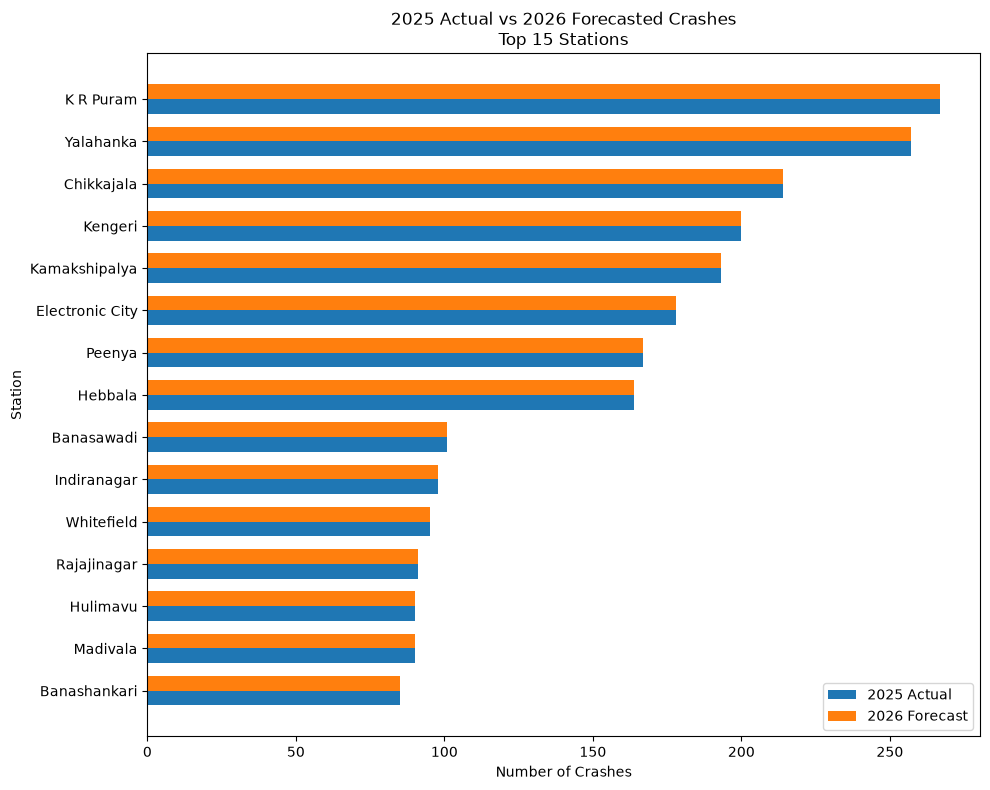

In [13]:
# ---------------------------------------------------------
# 2025 Actual vs 2026 Forecast
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Select top 15 stations by predicted 2026 crashes
plot_df = (
    predictive_df
    .sort_values(
        "predicted_2026_crashes",
        ascending=False
    )
    .head(15)
    .sort_values(
        "predicted_2026_crashes"
    )
)

plt.figure(figsize=(10, 8))

y = np.arange(len(plot_df))
height = 0.35

plt.barh(
    y - height / 2,
    plot_df["actual_2025_crashes"],
    height,
    label="2025 Actual"
)

plt.barh(
    y + height / 2,
    plot_df["predicted_2026_crashes"],
    height,
    label="2026 Forecast"
)

plt.yticks(
    y,
    plot_df["station"]
)

plt.xlabel("Number of Crashes")

plt.ylabel("Station")

plt.title(
    "2025 Actual vs 2026 Forecasted Crashes\n"
    "Top 15 Stations"
)

plt.legend()

plt.tight_layout()

plt.show()

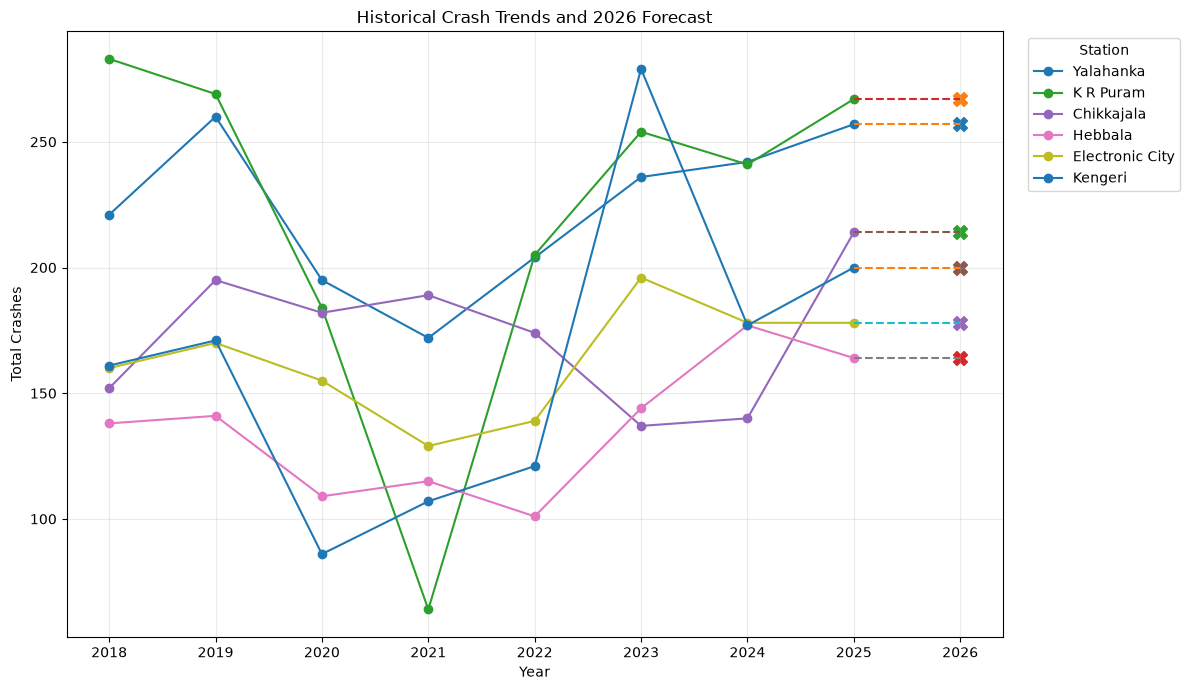

In [14]:
# ---------------------------------------------------------
# Historical Crash Trend + 2026 Forecast
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Select the top 6 stations from our predictive outlook
selected_stations = (
    predictive_df
    .head(6)["station"]
    .tolist()
)

plt.figure(figsize=(12, 7))

for station in selected_stations:

    # Historical data
    station_history = (
        df[df["station"] == station]
        .sort_values("year")
    )

    years = station_history["year"].values
    crashes = station_history["total_crashes"].values

    # 2026 forecast
    forecast_value = predictive_df.loc[
        predictive_df["station"] == station,
        "predicted_2026_crashes"
    ].iloc[0]

    # Plot historical values
    plt.plot(
        years,
        crashes,
        marker="o",
        label=station
    )

    # Connect 2025 to 2026 forecast
    plt.plot(
        [2025, 2026],
        [crashes[-1], forecast_value],
        linestyle="--"
    )

    # Mark forecast point
    plt.scatter(
        2026,
        forecast_value,
        marker="X",
        s=100
    )


plt.title(
    "Historical Crash Trends and 2026 Forecast"
)

plt.xlabel("Year")

plt.ylabel("Total Crashes")

plt.xticks(
    range(2018, 2027)
)

plt.legend(
    title="Station",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()